In [ ]:
import pandas as pd
from collections.abc import Iterable
import os
import glob

ET_DATA_DIR = "D:/LegoVR/unity-lego-vr/Other_than_in_project_files/ET_Data"

def load_participant_data(participant_numbers):
    """
    Load .csv data for one or multiple participants using the filename format.

    The date portion of the filename is discovered automatically per participant.

    Parameters:
        participant_numbers (int|str|Iterable): Single participant or iterable of participants.

    Returns:
        pd.DataFrame or None: Concatenated DataFrame with 'participant_id', or None if none found.
    """
    if isinstance(participant_numbers, (int, str)):
        participants = [participant_numbers]
    elif isinstance(participant_numbers, Iterable):
        participants = list(participant_numbers)
    else:
        raise TypeError("participant_numbers must be an int, str, or iterable of them")

    loaded_frames = []
    for p in participants:
        participant_id = f"{int(p):02d}"
        pattern = f"{participant_id}_ET_Data_*.csv"
        matches = sorted(glob.glob(os.path.join(ET_DATA_DIR, pattern)))
        if not matches:
            print(f"File not found for participant {participant_id}: {os.path.join(ET_DATA_DIR, pattern)}")
            continue
        file_path = matches[-1]  # pick the lexicographically latest (dates sort correctly as YYYY-MM-DD)
        try:
            df = pd.read_csv(file_path)
            df = df.copy()
            df["participant_id"] = participant_id
            print(f"Loaded data for participant {participant_id} from '{file_path}'")
            loaded_frames.append(df)
        except FileNotFoundError:
            print(f"File not found: {file_path}")

    if not loaded_frames:
        return None

    return pd.concat(loaded_frames, ignore_index=True)

# Example usage:
df = load_participant_data([1, 2, 3, 9])


Loaded data for participant 09 from 'D:/LegoVR/unity-lego-vr/Other_than_in_project_files/ET_Data/09_ET_Data_2025-08-29.csv'


In [36]:
df.columns

Index(['gaze_capture_time', 'raw_timestamp',
       'relative_to_unix_epoch_timestamp', 'focus_distance', 'frame_number',
       'stability', 'status', 'gaze_forward_x', 'gaze_forward_y',
       'gaze_forward_z', 'gaze_origin_x', 'gaze_origin_y', 'gaze_origin_z',
       'left_forward_x', 'left_forward_y', 'left_forward_z', 'left_origin_x',
       'left_origin_y', 'left_origin_z', 'left_status', 'left_pupil_diameter',
       'left_iris_diameter', 'left_pupil_iris_ratio', 'left_eye_openness',
       'right_forward_x', 'right_forward_y', 'right_forward_z',
       'right_origin_x', 'right_origin_y', 'right_origin_z', 'right_status',
       'right_pupil_diameter', 'right_iris_diameter', 'right_pupil_iris_ratio',
       'right_eye_openness', 'inter_pupillary_distance', 'hmd_position_x',
       'hmd_position_y', 'hmd_position_z', 'hmd_rotation_x', 'hmd_rotation_y',
       'hmd_rotation_z', 'hmd_rotation_w', 'model_name', 'is_building_model',
       'hit_obj_name', 'calibration_state', 'calibr

In [37]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,hmd_rotation_y,hmd_rotation_z,hmd_rotation_w,model_name,is_building_model,hit_obj_name,calibration_state,calibration_attempts,left_eye_calibration_quality,right_eye_calibration_quality
0,1000000469764589900,1756454144417,201.7003,0.931694,75290,0.286745,Valid,-0.101863,-0.169835,0.980194,...,0.717160,-0.127593,0.677673,NaN,False,work_desk_base.001,WaitingForUser,0,Unknown,Unknown
1,1000000469769591400,1756454144444,201.7003,0.922835,75291,0.273707,Valid,-0.095329,-0.169673,0.980879,...,0.717160,-0.127593,0.677673,NaN,False,work_desk_base.001,WaitingForUser,0,Unknown,Unknown
2,1000000469774592900,1756454144444,201.7003,0.914597,75292,0.248232,Valid,-0.089489,-0.169531,0.981453,...,0.717160,-0.127593,0.677673,NaN,False,work_desk_base.001,WaitingForUser,0,Unknown,Unknown
3,1000000469779594400,1756454144444,201.7003,0.906901,75293,0.235158,Valid,-0.084505,-0.169381,0.981921,...,0.717160,-0.127593,0.677673,NaN,False,work_desk_base.001,WaitingForUser,0,Unknown,Unknown
4,1000000469784595200,1756454144444,201.7003,0.900784,75294,0.226495,Valid,-0.080335,-0.169204,0.982302,...,0.717160,-0.127593,0.677673,NaN,False,work_desk_base.001,WaitingForUser,0,Unknown,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351402,1000003017181931100,1756456691350,2748.0670,0.822550,584578,0.000000,Valid,0.245298,-0.341096,0.907459,...,0.613745,-0.142128,0.775722,NaN,False,work_desk_base.001,Succeeded,0,High,High
351403,1000003017186933400,1756456691360,2748.0780,0.790443,584579,0.000000,Valid,0.239483,-0.341234,0.908959,...,0.619043,-0.141416,0.771581,NaN,False,work_desk_base.001,Succeeded,0,High,High
351404,1000003017191933700,1756456691360,2748.0780,0.771739,584580,0.000000,Valid,0.234248,-0.341027,0.910400,...,0.619043,-0.141416,0.771581,NaN,False,work_desk_base.001,Succeeded,0,High,High
351405,1000003017196934000,1756456691371,2748.0890,0.759945,584581,0.000000,Valid,0.227614,-0.340305,0.912351,...,0.624207,-0.140569,0.767522,NaN,False,work_desk_base.001,Succeeded,0,High,High


In [41]:
# Filter rows and make a copy to avoid SettingWithCopyWarning
df = df[(df["model_name"] != "TM") & (df["is_building_model"] == True)].copy()

# Determine the unique model names in order of appearance
unique_models = df["model_name"].drop_duplicates().tolist()

# Assign condition based on position of model in unique_models
model_to_condition = {}
for idx, model in enumerate(unique_models):
    if idx < 6:
        model_to_condition[model] = "constant"
    elif idx < 12:
        model_to_condition[model] = "0.7s delay"
    elif idx < 18:
        model_to_condition[model] = "2.0s delay"
    else:
        model_to_condition[model] = "unknown"

df.loc[:, "condition"] = df["model_name"].map(model_to_condition)

# Assign complexity_level based on model_name content
def get_complexity_level(model_name):
    if "C1" in model_name:
        return "easy"
    elif "C2" in model_name:
        return "medium"
    elif "C3" in model_name:
        return "high"
    else:
        return "unknown"

df.loc[:, "complexity_level"] = df["model_name"].apply(get_complexity_level)

# Assign 'Fam vs Abs' column: 'familiar' if 'F' in model_name, else 'abstract'
def get_fam_vs_abs(model_name):
    return "familiar" if "F" in model_name else "abstract"

df.loc[:, "Fam_Abs"] = df["model_name"].apply(get_fam_vs_abs)

df.head()

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_name,is_building_model,hit_obj_name,calibration_state,calibration_attempts,left_eye_calibration_quality,right_eye_calibration_quality,condition,complexity_level,Fam_Abs
75488,1000000923028678100,1756454597216,654.3512,2.0,165908,0.890708,Valid,-0.040671,0.128306,0.990900,...,C3M2A,True,Wall_Front,Succeeded,0,High,High,constant,high,abstract
75489,1000000923033679600,1756454597216,654.3512,2.0,165909,0.889633,Valid,-0.040742,0.128401,0.990885,...,C3M2A,True,Wall_Front,Succeeded,0,High,High,constant,high,abstract
75490,1000000923038680100,1756454597216,654.3512,2.0,165910,0.858236,Valid,-0.040910,0.128424,0.990875,...,C3M2A,True,Wall_Front,Succeeded,0,High,High,constant,high,abstract
75491,1000000923043680200,1756454597216,654.3512,2.0,165911,0.845689,Valid,-0.041090,0.128406,0.990870,...,C3M2A,True,Wall_Front,Succeeded,0,High,High,constant,high,abstract
75492,1000000923048680700,1756454597216,654.3512,2.0,165912,0.812906,Valid,-0.041138,0.128408,0.990868,...,C3M2A,True,Wall_Front,Succeeded,0,High,High,constant,high,abstract


In [ ]:
import numpy as np

filtered_df = df[(df["model_name"] != "TM") & (df["is_building_model"] == True)][["participant_id", "gaze_capture_time", "model_name", "hit_obj_name","condition"]]

# Ensure gaze_capture_time is numeric
filtered_df = filtered_df.copy()
filtered_df["gaze_capture_time"] = pd.to_numeric(filtered_df["gaze_capture_time"], errors="coerce")

# Collect all model streaks results across participants and models
all_streaks = []

# Calculate consecutive Model_plate streaks and durations per participant and per model
for (pid, model), model_group in filtered_df.groupby(["participant_id", "model_name"]):
    model_group_sorted = model_group.sort_values("gaze_capture_time").reset_index(drop=True)
    mask = model_group_sorted["hit_obj_name"] == "Model_plate"
    # Mark the start of each new streak of consecutive Model_plate
    streak_id = (mask != mask.shift()).cumsum()
    model_group_sorted["streak_id"] = streak_id

    for streak_num, streak_df in model_group_sorted.groupby("streak_id"):
        if streak_df["hit_obj_name"].iloc[0] == "Model_plate":
            start_time = streak_df["gaze_capture_time"].iloc[0]
            end_time = streak_df["gaze_capture_time"].iloc[-1]
            duration_ns = (end_time - start_time)
            if duration_ns < 0 or np.isnan(duration_ns):
                duration_ns = np.nan
                duration_ms = np.nan
                duration_s = np.nan
            else:
                duration_ms = duration_ns / 1e6
                duration_s = duration_ns / 1e9
            all_streaks.append({
                "participant_id": pid,
                "model_name": model,
                "start_time": start_time,
                "end_time": end_time,
                "duration_ns": duration_ns,
                "duration_ms": duration_ms,
                "duration_s": duration_s,
                "num_gaze": len(streak_df),
                "condition": model_to_condition[model],
                "complexity_level": get_complexity_level(model),
                "Fam_Abs": get_fam_vs_abs(model)
            })

# Compile all streaks into one DataFrame for all participants and models
model_plate_streaks_df = pd.DataFrame(all_streaks)

# The resulting DataFrame now includes participant_id and durations per streak.
display(model_plate_streaks_df)

,model_name,start_time,end_time,duration_ns,duration_ms,duration_s,num_gaze,condition,complexity_level,Fam_Abs
0,C1M1F,1000001823119220300,1000001824119345500,1000125200,1000.1252,1.000125,1,0.7s delay,easy,familiar
1,C1M2A,1000002680988494000,1000002680988494000,0,0.0000,0.000000,1,2.0s delay,easy,abstract
2,C1M2A,1000002680998494000,1000002684759970200,3761476200,3761.4762,3.761476,1,2.0s delay,easy,abstract
3,C1M3F,1000002806016280700,1000002807181428300,1165147600,1165.1476,1.165148,1,2.0s delay,easy,familiar
4,C1M4A,1000001063662415400,1000001067773927500,4111512100,4111.5121,4.111512,1,constant,easy,abstract
...,...,...,...,...,...,...,...,...,...,...
113,C3M6A,1000002109788400600,1000002111339583600,1551183000,1551.1830,1.551183,1,0.7s delay,high,abstract
114,C3M6A,1000002119202578800,1000002119202578800,0,0.0000,0.000000,1,0.7s delay,high,abstract
115,C3M6A,1000002119267587700,1000002121242838900,1975251200,1975.2512,1.975251,1,0.7s delay,high,abstract
116,C3M6A,1000002125249344600,1000002126270474300,1021129700,1021.1297,1.021130,1,0.7s delay,high,abstract


In [43]:
# Count the unique model_name per condition and complexity_level
unique_models_per_condition = model_plate_streaks_df.groupby(['condition', 'complexity_level', 'Fam_Abs'])['model_name'].nunique()
print(unique_models_per_condition)

condition   complexity_level  Fam_Abs 
0.7s delay  easy              abstract    1
                              familiar    1
            high              abstract    1
                              familiar    1
            medium            abstract    1
                              familiar    1
2.0s delay  easy              abstract    1
                              familiar    1
            high              abstract    1
                              familiar    1
            medium            abstract    1
                              familiar    1
constant    easy              abstract    1
                              familiar    1
            high              abstract    1
                              familiar    1
            medium            abstract    1
                              familiar    1
Name: model_name, dtype: int64


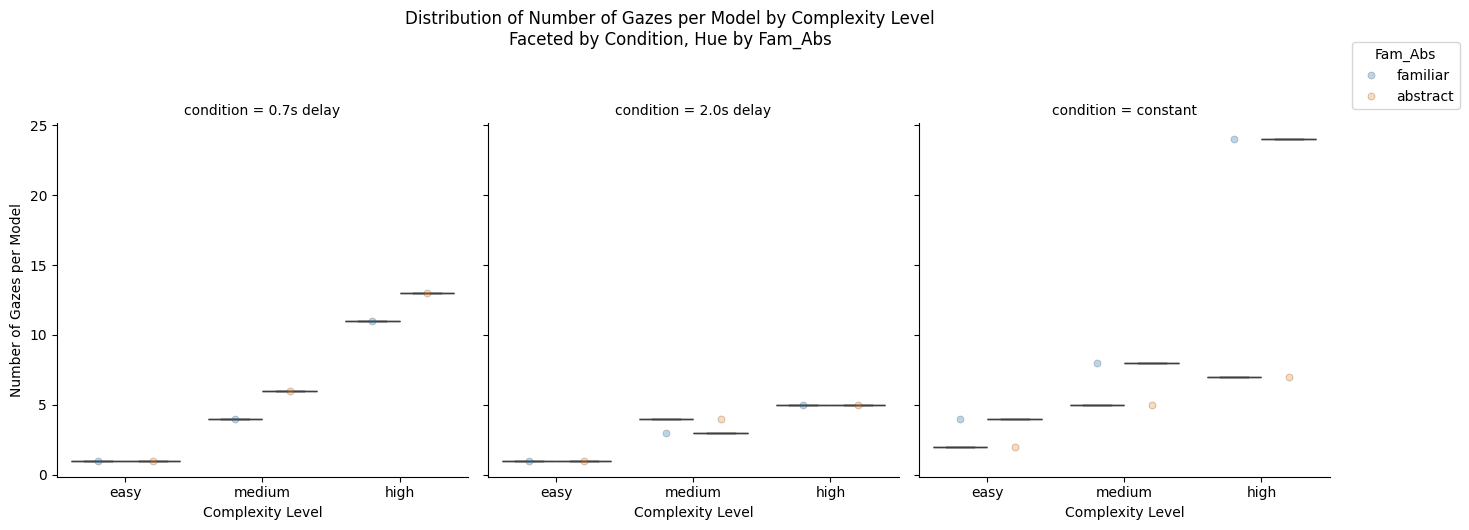

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for gaze durations greater or equal to 100 ms
filtered_df_viz = model_plate_streaks_df[model_plate_streaks_df["duration_ms"] >= 100]

# Count number of gazes per model_name
gaze_counts = (
    filtered_df_viz
    .groupby(["model_name", "complexity_level", "condition", "Fam_Abs"])["num_gaze"]
    .sum()
    .reset_index()
)

# Set up subplot by 'condition', hue by 'Fam_Abs'
g = sns.catplot(
    x="complexity_level",
    y="num_gaze",
    hue="Fam_Abs",
    col="condition",
    data=gaze_counts,
    kind="box",
    height=5,
    aspect=0.9,
    showfliers=False,
    legend=False  # Don't draw legend here; we'll draw one manually
)

# Overlay stripplot (jittered points) on each facet
# Collect handles/labels only from the first stripplot, for the legend
legend_handles = None
legend_labels = None

for ax_idx, (ax, (_, subdata)) in enumerate(zip(g.axes.flatten(), gaze_counts.groupby("condition"))):
    strip = sns.stripplot(
        x="complexity_level",
        y="num_gaze",
        hue="Fam_Abs",
        data=subdata,
        dodge=True,
        jitter=0.15,
        alpha=0.3,
        marker='o',
        ax=ax,
        linewidth=0.6,
        edgecolor='auto'
    )
    if ax_idx == 0:  # Get legend from the first
        legend_handles, legend_labels = strip.get_legend_handles_labels()
    # Remove legends from facet axes
    ax.legend_.remove() if ax.get_legend() else None

# Add a single legend for hue ("Fam_Abs")
if legend_handles is not None and legend_labels is not None:
    g.fig.legend(
        legend_handles, legend_labels, 
        title="Fam_Abs",
        loc='upper left', bbox_to_anchor=(1, 1)
    )

g.set_axis_labels("Complexity Level", "Number of Gazes per Model")
g.fig.suptitle("Distribution of Number of Gazes per Model by Complexity Level\nFaceted by Condition, Hue by Fam_Abs", y=1.05)
plt.tight_layout()
plt.show()